### Running the RL agent on-the-fly on Matt's hardware

In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.extensions import UnitaryGate
from qsimh import get_rdms_via_tomography, get_next_unitary, get_exact_two_qubit_rdms, compute_fidelities, compute_entanglement_entropy

/opt/homebrew/Caskroom/miniforge/base/envs/matt2/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [4]:
n = 4 # number of qubits
initial_state_params = np.load("initial_params.npy") # same parameters as before

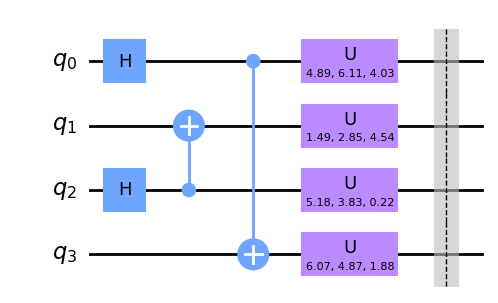

In [5]:
qc = QuantumCircuit(n)
qc.h(2)
qc.cx(2,1)
qc.h(0)
qc.cx(0,3)
for i in range(n):
    qc.u(initial_state_params[0,i], initial_state_params[1,i], initial_state_params[2,i], i)

# add a barrier so that the transpilation of the upper and lower half of the circuit is not mixed.
qc.barrier()
qc.draw('mpl')

The following data you already have, so there is no need in taking it again.

In [6]:
n_shots = 2000
data = np.load("Data_BeforeDA_FlipOdd.npy") # raw measurement data (flipped)

Given the data, we perform quantum state tomography and feed the data to the RL agent. 
The function below returns the next unitary to be applied to the circuit and the qubit indices on which it acts.

In [7]:
U, qubit_indices = get_next_unitary(data, qc, n_shots)

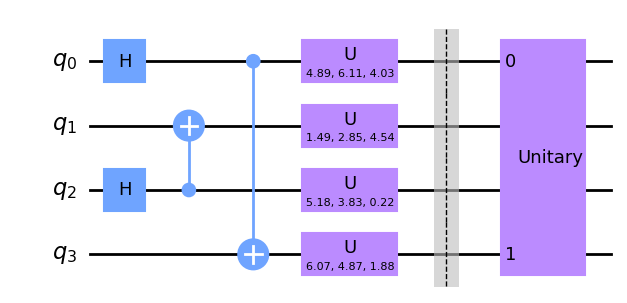

In [8]:
# append unitary to the circuit
qc.append(UnitaryGate(U), qubit_indices)
qc.draw('mpl')

### This part is new!!

After applying the new unitary above, you have to perform the same measurements as before again on the updated circuit. Once you have the data, you can execute the lines below to append the final disentangling unitary.

In [ ]:
data = np.load("Data_AfterFirstDisentanglingGate_FlipOdd.npy") # new data after measuring the circuit above
U, qubit_indices = get_next_unitary(data, qc, n_shots)
qc.append(UnitaryGate(U), qubit_indices)
qc.draw('mpl')

And finally, you have to perform all the measurements one last time to see if the state is fully disentangled. Please check that the printed circuit above makes sense before performing the expensive measurements. The qubit indices should correspond to the two qubits in the middle.

In [ ]:
data = np.load("Data_AfterDA_FlipOdd_new.npy")
rdms = get_rdms_via_tomography(data.copy(), qc.copy(), n_shots)
ent_hardware = compute_entanglement_entropy(rdms)

Once you have completed all measurements, please send me all the shot data, so I can analyze it as well. Thanks a lot! :)